In [1115]:
from importlib import reload
import MLPModel, LinearModel 
import Model_Training
import numpy as np

reload(MLPModel)
reload(LinearModel)
reload(Model_Training)

import torch
seed = 31
torch.manual_seed(seed)


In [1116]:


ticker = "AAPL"
start = '2022-01-01'    # start date
end  = '2026-01-01'     # end date
interval = '1d'         # interval
train_ratio = 0.5
no_epoches = 100_000
lr = 0.001
tx_fees_bpts = 10
threshold = 0.001

weight_decay = 1e-3

max_lags = 12

modelMLP = MLPModel.MLP # multiplayer perception 

Model = Model_Training.model_training(model = modelMLP(max_lags),
                              tick = ticker,
                              start = start,
                              end = end ,
                              interval = interval,
                              train_ratio = train_ratio,
                              max_lags = max_lags,
                              no_epochs=no_epoches,
                              lr = lr,
                              rtol = 1e-5,
                              trade_signal = "threshold",
                              threshold=threshold,
                              transaction_cost_bpts= tx_fees_bpts,
                              verbose = True,
                              weight_decay= weight_decay)

modelLinear = LinearModel.LinearModel # Linear Model equivalent to AR tine series

ModelLin = Model_Training.model_training(model = modelLinear(max_lags),
                              tick = ticker,
                              start = start,
                              end = end ,
                              interval = interval,
                              train_ratio = train_ratio,
                              max_lags = max_lags,
                              no_epochs=no_epoches,
                              lr = lr,
                              rtol = 1e-5 ,
                              trade_signal = "threshold",
                              threshold=threshold,
                              transaction_cost_bpts= tx_fees_bpts,
                              verbose = True,
                              weight_decay= weight_decay)



[*********************100%***********************]  1 of 1 completed


Training model...
Epoch 0/100000, Loss = 1.025663614
Epoch 500/100000, Loss = 0.640333593


[*********************100%***********************]  1 of 1 completed

Epoch 1000/100000, Loss = 0.543075442
Relative Tolance Reached at Epoch 1498

 Training Finished! 
 Loss = 0.463636547
Test Loss = 1.297424912

Test Loss = 0.000436970 
Train Loss = 0.000156131

Training model...
Epoch 0/100000, Loss = 1.299320459
Relative Tolance Reached at Epoch 429

 Training Finished! 
 Loss = 0.968640447
Test Loss = 0.960264146

Test Loss = 0.000323415 
Train Loss = 0.000326233



Test Loss = 0.000436970 
Train Loss = 0.000156131

Test Loss = 0.000323415 
Train Loss = 0.000326233


Text(0.5, 1.0, 'Linear Model')

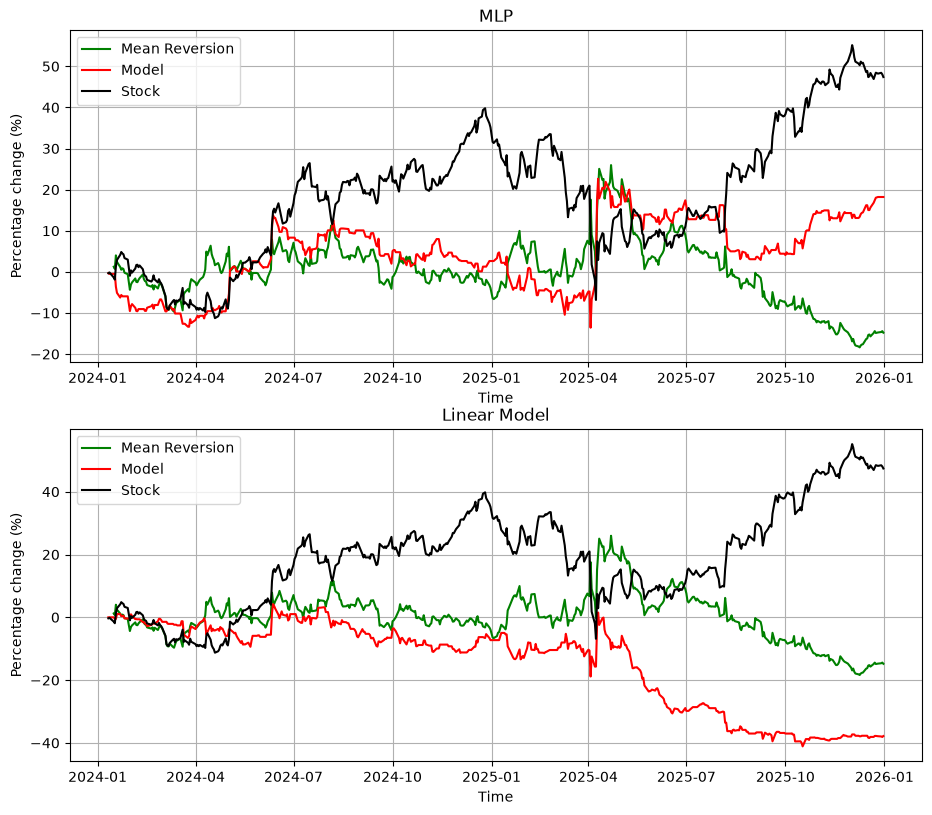

In [1117]:

fx_fees_bpts = 0
threshold = 0.001#0.0000001

Model.get_MR_results()
MR_df = Model.MR_df
MR_cum_return = np.expm1(MR_df["trade_log_return_cum"]) * 100


import matplotlib.pyplot as plt
fig, (ax1,ax2) = plt.subplots(2,1, figsize = (11,9.5))

Model.get_trade_results(trade_signal="threshold",threshold=threshold, transaction_fees_bpts= fx_fees_bpts)
ModelLin.get_trade_results(trade_signal="threshold",threshold=threshold, transaction_fees_bpts= fx_fees_bpts)

ax1.plot(Model.date_test,MR_cum_return,c='green',label='Mean Reversion')
ax2.plot(Model.date_test,MR_cum_return,c='green',label='Mean Reversion')

Model.model_against_stock(ax1)
ModelLin.model_against_stock(ax2)


ax1.set_title("MLP")
ax2.set_title("Linear Model")



# Model.date_test

Overall IC: 0.12058452407399517
Mean rolling IC: 0.035236554407119314
Positive-window fraction: 0.5708154506437768
Minimum: -0.2632562573349038
Maximum: 0.4785301792070313
Win_Rate: 0    0.357576
Name: win_rate, dtype: float64

Overall IC: -0.041663647185485674
Mean rolling IC: -0.04508276161561011
Positive-window fraction: 0.45493562231759654
Minimum: -0.5981092315961689
Maximum: 0.2839435384674383
Win_Rate: 0    0.29697
Name: win_rate, dtype: float64


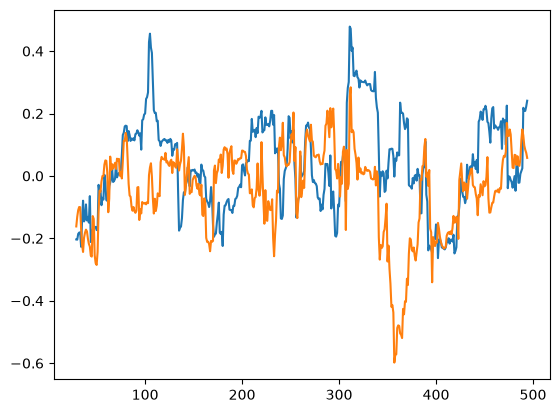

In [1118]:

df = Model.trade_results


rolling_ic = df["rolling_IC"].dropna()
df["rolling_IC"].plot()

print("Overall IC:", df["T_hat"].corr(df["T_test"]))
print("Mean rolling IC:", rolling_ic.mean())
print("Positive-window fraction:", (rolling_ic > 0).mean())
print("Minimum:", rolling_ic.min())
print("Maximum:", rolling_ic.max())
print("Win_Rate:", Model.performance_df["win_rate"])



df = ModelLin.trade_results


rolling_ic = df["rolling_IC"].dropna()
df["rolling_IC"].plot()

print("\nOverall IC:", df["T_hat"].corr(df["T_test"]))
print("Mean rolling IC:", rolling_ic.mean())
print("Positive-window fraction:", (rolling_ic > 0).mean())
print("Minimum:", rolling_ic.min())
print("Maximum:", rolling_ic.max())
print("Win_Rate:", ModelLin.performance_df["win_rate"])

In [1119]:
tx_cost = 1


Model.get_trade_results("sign",0.001,transaction_fees_bpts=tx_cost)
Model.get_model_performance()
Model.model_against_stock()

ModelLin.get_trade_results("sign",0.001,transaction_fees_bpts=tx_cost)
ModelLin.get_model_performance()
ModelLin.model_against_stock()


Test Loss = 0.000436970 
Train Loss = 0.000156131


TypeError: model_training.get_model_performance() missing 1 required positional argument: 'df'


Test Loss = 0.000583750 
Train Loss = 0.000570300

Maximum drawdown (log): -0.320021
Drawdown percentage: -27.39%
Win rate: 48.84%
Average win: 0.016395
Average loss: -0.016257
Expected value per trade: -0.000311
Total log return: -0.106871
Compounded return: -10.14%
Equity multiplier: 0.8986x
Minimum trade log return: -0.110853
Maximum trade log return: 0.209169
Standard deviation: 0.023126
Annualized Sharpe (stocks): -0.2133
Annualized Sharpe (crypto): -0.2567


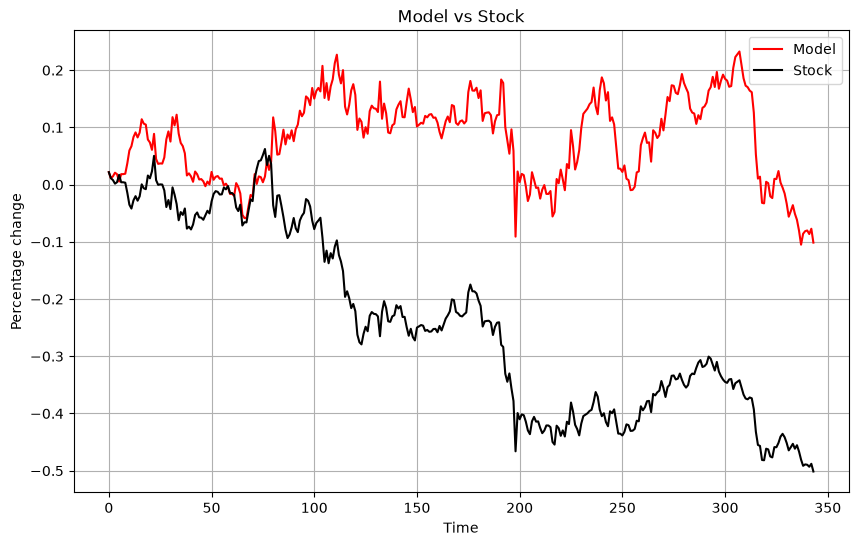


Test Loss = 0.000549260 
Train Loss = 0.000624146

Maximum drawdown (log): -0.413588
Drawdown percentage: -33.87%
Win rate: 49.13%
Average win: 0.015902
Average loss: -0.016732
Expected value per trade: -0.000700
Total log return: -0.240630
Compounded return: -21.39%
Equity multiplier: 0.7861x
Minimum trade log return: -0.302902
Maximum trade log return: 0.115234
Standard deviation: 0.023118
Annualized Sharpe (stocks): -0.4803
Annualized Sharpe (crypto): -0.5781


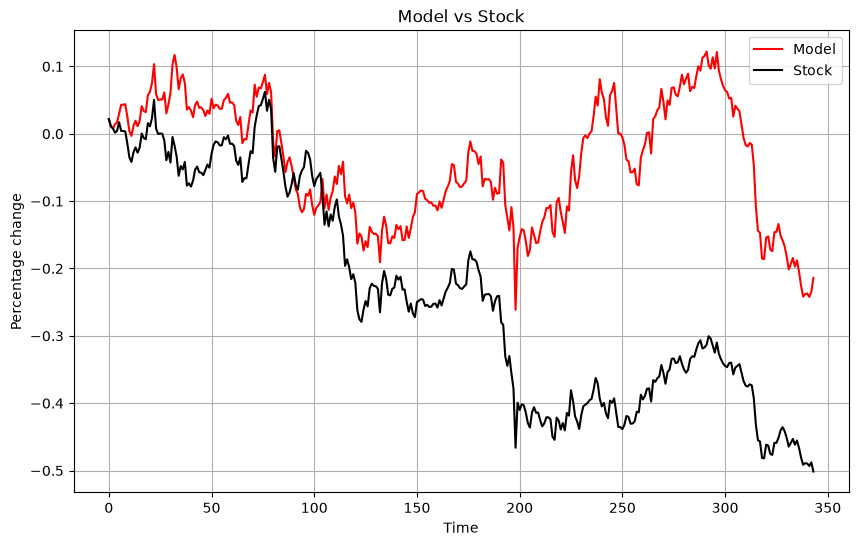

In [102]:
Model.get_trade_results("threshold",0.0001)
Model.get_model_performance()
Model.model_against_stock()

ModelLin.get_trade_results("threshold",0.0001)
ModelLin.get_model_performance()
ModelLin.model_against_stock()

In [103]:
print("MPL: ")
for name, param in Model.model.named_parameters():
    print(name, param, param.requires_grad)

print("Linear: ")
for name, param in ModelLin.model.named_parameters():
    print(name, param, param.requires_grad)

MPL: 
network.0.weight Parameter containing:
tensor([[ 5.8310e-01, -4.6052e-02, -2.2985e-01,  9.5409e-02, -1.4395e-01,
         -4.7228e-01, -8.2048e-01,  1.2247e-01, -1.0981e-01,  7.0845e-02,
         -6.4343e-02,  3.0969e-01,  1.5342e-02, -9.6783e-01,  3.7592e-01,
         -5.0476e-01,  2.8569e-01, -4.9914e-01,  2.2597e-01,  1.2685e+00,
          2.9883e-02,  9.2455e-01],
        [-4.3977e-01,  2.3457e-01, -3.7606e-01, -1.8123e-01, -5.4885e-02,
          5.6008e-01,  4.2891e-01,  4.1621e-01,  5.1721e-02, -7.9423e-02,
          2.9018e-02,  2.1350e-01,  7.5709e-03,  2.8425e-01,  7.0982e-02,
          8.3547e-01,  4.1094e-01,  2.2529e-01,  2.9530e-01,  2.2213e-01,
          8.7241e-01,  6.7225e-01],
        [ 1.2324e-01, -9.3205e-02,  1.2307e-01,  3.8147e-02,  1.0827e-01,
         -1.2995e-01, -2.1105e-01, -8.2372e-02, -1.6353e-01,  1.7494e-01,
          6.1408e-02,  8.8311e-02,  6.7427e-02, -3.7088e-03,  1.6685e-01,
         -1.5148e-01,  1.3424e-02, -1.4552e-01,  6.5741e-02, -7.3423e